<a href="https://colab.research.google.com/github/ellaluedeke/llm-student-misconceptions/blob/main/evaluation_streamline_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ollama

In [ ]:
!ollama pull llama3.2
!ollama pull mistral
!ollama list



NAME               ID              SIZE      MODIFIED               
mistral:latest     6577803aa9a0    4.4 GB    Less than a second ago    
llama3.2:latest    a80c4f17acd5    2.0 GB    29 seconds ago            


In [ ]:

import ollama
current_model = "llama3.2"
response = ollama.chat(model=current_model, messages=[{"role": "user", "content": "please introduce yourself"}])
print(response);

model='llama3.2' created_at='2025-09-25T01:12:23.169112763Z' done=True done_reason='stop' total_duration=4183049009 load_duration=2651792008 prompt_eval_count=28 prompt_eval_duration=453795961 eval_count=144 eval_duration=1076598431 message=Message(role='assistant', content='Nice to meet you! I\'m an AI designed to assist and communicate with users like you. My primary function is to provide information, answer questions, and engage in conversation to the best of my abilities.\n\nI don\'t have a personal name, but I can refer to myself as a "Language Model" or a "Conversational AI." I was created using advanced machine learning algorithms and natural language processing techniques, allowing me to understand and generate human-like text.\n\nMy knowledge base is constantly updated and expanded to provide accurate and informative responses on a wide range of topics. I\'m here to help answer any questions you may have, offer suggestions, or simply engage in a conversation.\n\nHow can I ass

In [ ]:
!pip install -q ollama pandas tqdm

import pandas as pd
from tqdm import tqdm
import ollama
import re

# ---- CONFIG ----
DATA_PATH = "/content/UNIT_1_READING_test.csv"

PROMPT_TYPES = ["zero_shot", "few_shot", "rte"]

# ---- PROMPT TEMPLATES ----
PROMPTS = {
    "zero_shot": lambda text: f"""
You are an expert physics professor looking for misconceptions in student responses.
-'alts' = acceleration limited to speed, which is when students associate acceleration with only speeding up and slowing down.

Student response:
{text}

Task: Output ONLY a 0 if it does not contain the misconception or 1 if it does.
""",
    "few_shot": lambda text: f"""
You are an expert physics professor looking for misconceptions in student responses.
-'alts' = acceleration limited to speed, which is when students associate acceleration with only speeding up and slowing down.

Here are examples that contain the misconception.
- an object with constant acceleration will speed up continuously, an object with constant speed will hold that speed
- the difference between an object with constant acceleration and an object with constant speed is that an object with constant speed is not accelerating at all so its acceleration is net zero
- an object with constant acceleration gets faster and faster or slower and slower and an object with constant speed stays the same speed
- an object with constant acceleration is experiencing a constant increase in its speed, whereas an object with constant speed is not accelerating
- the difference between an object with constant acceleration and an object with constant speed is that the object with constant speed will not accelerate, and the object with constant acceleration will continue to increase speed

Here are examples that do not contain the misconception.
- unlike an object with constant acceleration, its speed will constantly increase over time
- an object with a constant speed will move slower than an object with a constant acceleration
- the difference between an object with constant acceleration and constant speed is that the object with constant acceleration will become faster, while the object with the constant speed will stay the same speed
- this makes sense because he has a constant acceleration, so his velocity will increase at a constant rate
- this makes sense because the constant acceleration is causing the velocity to increase

Student response:
{text}

Task: Output ONLY a 0 if it does not contain the misconception or 1 if it does.
""",
    "rte": lambda text: f"""
You are an expert physics professor grading student responses.

Perfect answers:
- He moves to the right and gets faster
- Constant speed means no acceleration; constant acceleration changes velocity at a steady rate

Student Response: {text}
Task: Output ONLY a 0 if it does not contradict or 1 if it does.
"""
}

# ---- LOAD DATA ----
df = pd.read_csv(DATA_PATH)
results = pd.DataFrame({"sentence": df["sentence"], "ground_truth": df["alts"].astype(int)})

# ---- CLASSIFICATION FUNCTION ----
def classify_with_ollama(model_name, prompt):
    try:
        response = ollama.chat(model=model_name, messages=[{"role": "user", "content": prompt}])

        # Access the message content
        text = ""
        if hasattr(response, "message") and response.message:
            text = response.message.content
        elif "content" in response:
            text = response["content"]

        text = text.strip().lower()

        # Extract first standalone 0 or 1 at the beginning
        match = re.match(r"[01]", text)
        if match:
            return match.group(0)

        # fallback: if text contains 'contains' or 'yes', assume 1
        #if "contains" in text or "yes" in text:
         #   return "1"
        return "0"

    except Exception as e:
        print(f"[ERROR] {model_name} failed: {e}")
        return "0"

# ---- RUN PIPELINE ----
def run_pipeline(model_name):
    print(f"Running classification with model: {model_name}")
    for prompt_type in PROMPT_TYPES:
        col_name = f"{prompt_type}_{model_name}"
        results[col_name] = None

        for idx, text in tqdm(enumerate(df["sentence"]), total=len(df), desc=f"{prompt_type}-{model_name}"):
            prompt = PROMPTS[prompt_type](text)
            results.at[idx, col_name] = classify_with_ollama(model_name, prompt)

    # Save CSV
    results.to_csv(f"train_filter_results_{model_name}.csv", index=False)
    print(f"Saved results to train_filter_results_{model_name}.csv")

#choose model
run_pipeline("gpt-oss:120b")


Running classification with model: gpt-oss:120b


rte-gpt-oss:120b: 100%|██████████| 213/213 [09:00<00:00,  2.54s/it]

Saved results to train_filter_results_gpt-oss:120b.csv


In [ ]:
import pandas as pd
from sklearn.metrics import f1_score
import glob
import os

# ---- CONFIG ----
MODEL_CSV_DIR = "/content/train_filter/"  # folder with 5 CSVs (each model)
OUTPUT_CSV = "/content/majority_votes_train_filter.csv"

# ---- FUNCTIONS ----
def majority_vote_across_models(votes):
    """votes is a list or Series of 0/1 from different models"""
    votes = [int(v) for v in votes]
    return 1 if sum(votes) > len(votes)/2 else 0

# ---- LOAD ALL MODEL CSVs ----
model_files = glob.glob(os.path.join(MODEL_CSV_DIR, "*.csv"))

dfs = [pd.read_csv(f) for f in model_files]

# Check that all CSVs have same length and same student responses
for i, df in enumerate(dfs[1:], 1):
    if not dfs[0]['sentence'].equals(df['sentence']):
        raise ValueError(f"Student responses do not match in CSV {model_files[i]}")

# ---- PREP OUTPUT DATAFRAME ----
out_df = dfs[0][['sentence', 'ground_truth']].copy()
prompt_types = set()
for c in dfs[0].columns[2:]:
    prompt_types.add(c.split('_')[0])

# ---- COMPUTE MAJORITY VOTES PER PROMPT TYPE ----
for prompt in prompt_types:
    # collect all model columns for this prompt
    cols_per_model = [df[[c for c in df.columns if c.startswith(prompt)]].iloc[:,0] for df in dfs]

    # transpose so we have one row = votes from all models for this prompt
    votes_matrix = pd.concat(cols_per_model, axis=1)

    # apply majority vote row-wise
    out_df[f"{prompt}_majority"] = votes_matrix.apply(majority_vote_across_models, axis=1)

# ---- CALCULATE F1 SCORES ----
f1_results = {}
for prompt in prompt_types:
    f1 = f1_score(out_df['ground_truth'], out_df[f"{prompt}_majority"])
    print(f"{prompt}_majority F1: {f1:.4f}")
    f1_results[prompt] = f1

# ---- SAVE OUTPUT ----
out_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved majority vote CSV to {OUTPUT_CSV}")


few_majority F1: 0.2759
rte_majority F1: 0.1250
zero_majority F1: 0.1207
Saved majority vote CSV to /content/majority_votes_train_filter.csv


rte_majority F1: 0.1250


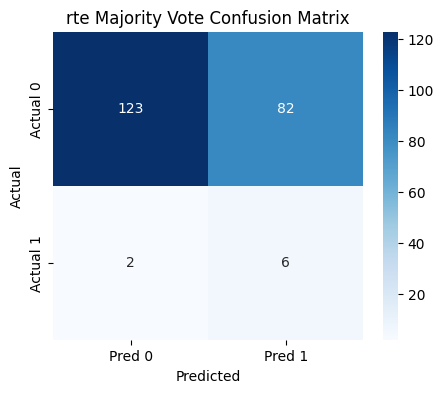

zero_majority F1: 0.1207


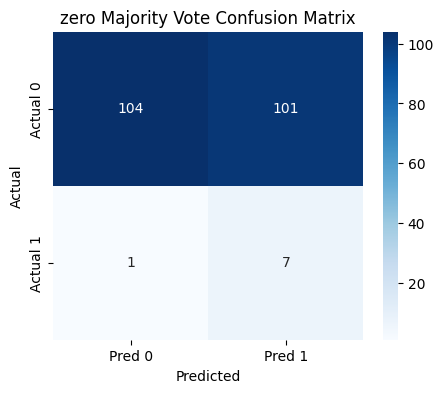

few_majority F1: 0.2759


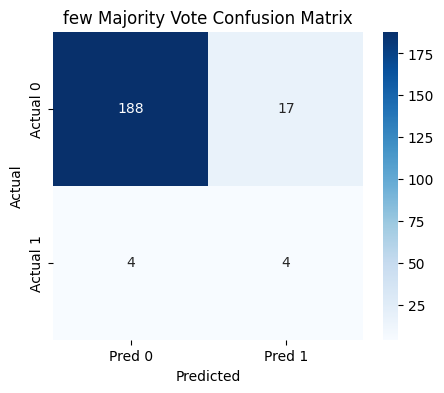

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the completed majority vote CSV
csv_path = "/content/majority_votes_train_filter.csv"  # adjust path
df = pd.read_csv(csv_path)

prompt_types = ['rte', 'zero', 'few']  # adjust if different
metrics_summary = []

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for prompt in prompt_types:
    maj_col = f"{prompt}_majority"

    # Ensure integer type
    y_pred = df[maj_col].astype(int)
    y_true = df['ground_truth'].astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=1)
    metrics_summary.append({"prompt_type": prompt, "f1": f1})

    print(f"{prompt}_majority F1: {f1:.4f}")

    # Plot confusion matrix
    plot_confusion(y_true, y_pred, title=f"{prompt} Majority Vote Confusion Matrix")



CSV: train_filter_results_phi4.csv
zero_shot_phi4: Accuracy=0.5352 | Precision=0.0309 | Recall=0.3750 | F1=0.0571


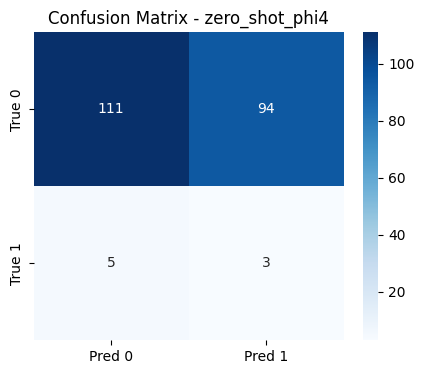

few_shot_phi4: Accuracy=0.8404 | Precision=0.0938 | Recall=0.3750 | F1=0.1500


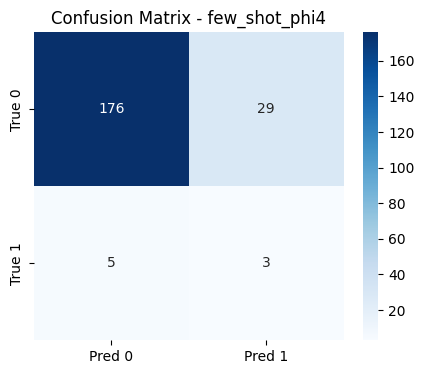

rte_phi4: Accuracy=0.4319 | Precision=0.0407 | Recall=0.6250 | F1=0.0763


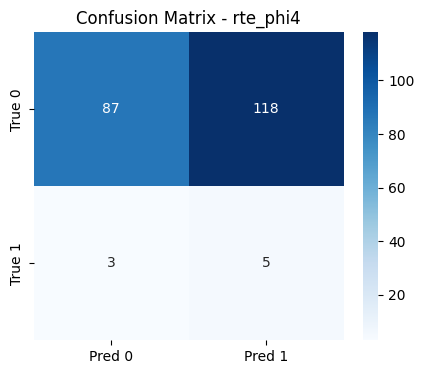


CSV: train_filter_results_llama3.2.csv
zero_shot_llama3.2: Accuracy=0.2817 | Precision=0.0440 | Recall=0.8750 | F1=0.0838


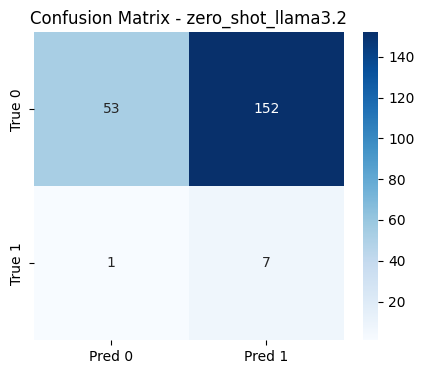

few_shot_llama3.2: Accuracy=0.5728 | Precision=0.0337 | Recall=0.3750 | F1=0.0619


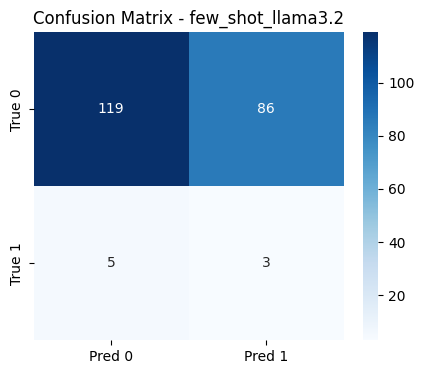

rte_llama3.2: Accuracy=0.6479 | Precision=0.0533 | Recall=0.5000 | F1=0.0964


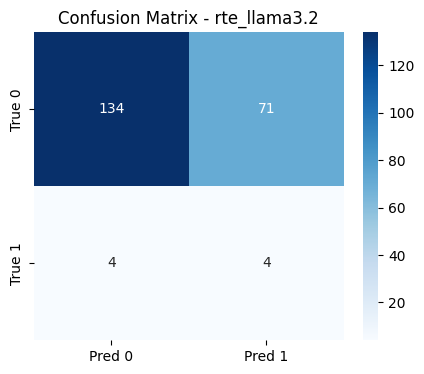


CSV: train_filter_results_gpt-oss:120b.csv
zero_shot_gpt-oss:120b: Accuracy=0.6761 | Precision=0.0933 | Recall=0.8750 | F1=0.1687


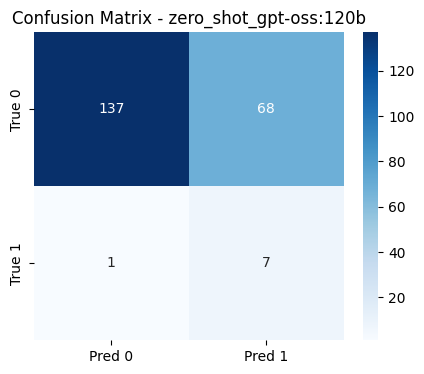

few_shot_gpt-oss:120b: Accuracy=0.7606 | Precision=0.1091 | Recall=0.7500 | F1=0.1905


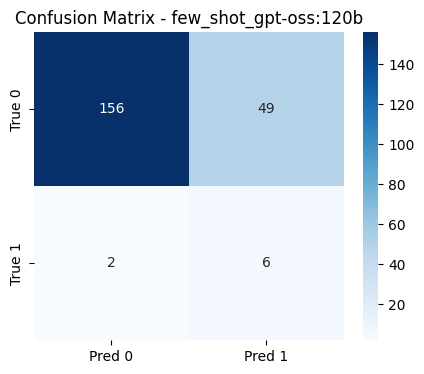

rte_gpt-oss:120b: Accuracy=0.8075 | Precision=0.0286 | Recall=0.1250 | F1=0.0465


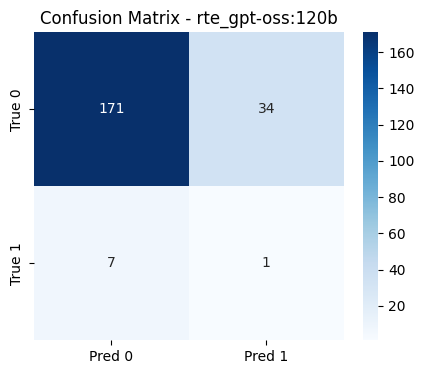


CSV: train_filter_results_mistral.csv
zero_shot_mistral: Accuracy=0.0751 | Precision=0.0345 | Recall=0.8750 | F1=0.0664


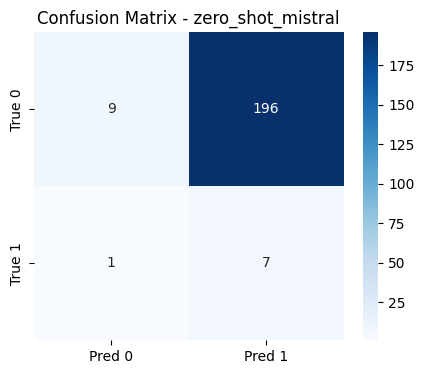

few_shot_mistral: Accuracy=0.8732 | Precision=0.1481 | Recall=0.5000 | F1=0.2286


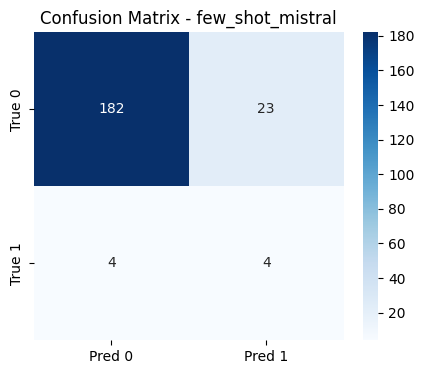

rte_mistral: Accuracy=0.0939 | Precision=0.0398 | Recall=1.0000 | F1=0.0766


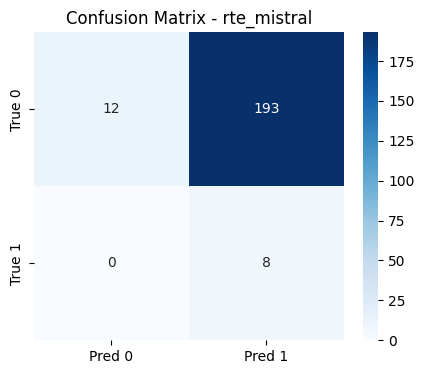


CSV: train_filter_results_qwen2.5.csv
zero_shot_qwen2.5: Accuracy=0.8685 | Precision=0.1875 | Recall=0.7500 | F1=0.3000


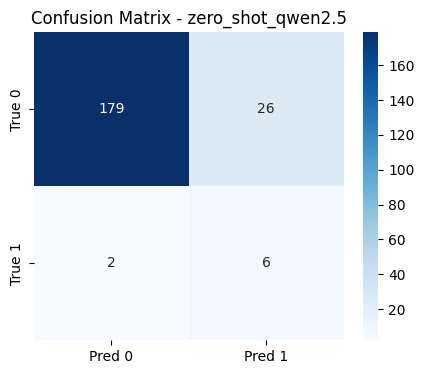

few_shot_qwen2.5: Accuracy=0.8451 | Precision=0.0370 | Recall=0.1250 | F1=0.0571


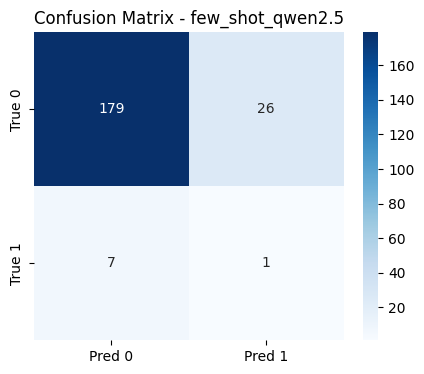

rte_qwen2.5: Accuracy=0.7042 | Precision=0.1014 | Recall=0.8750 | F1=0.1818


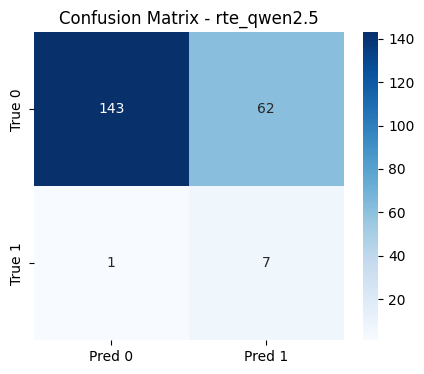

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Replace with your folder
folder = "/content/train_filter"  # or "/content/results/unfiltered"
csv_files = glob.glob(os.path.join(folder, "*.csv"))

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    print(f"\nCSV: {os.path.basename(csv_path)}")

    if "ground_truth" not in df.columns:
        raise ValueError(f"No 'ground_truth' column in {csv_path}")

    ground_truth = df["ground_truth"].astype(int)

    # Skip first two columns (student_response, ground_truth)
    prompt_cols = df.columns[2:]

    for col in prompt_cols:
        # Convert to binary: anything containing "1" -> 1, else 0
        preds = df[col].astype(str).str.contains("1").astype(int)

        # Compute metrics
        acc = accuracy_score(ground_truth, preds)
        prec = precision_score(ground_truth, preds, zero_division=1)
        rec = recall_score(ground_truth, preds, zero_division=1)
        f1 = f1_score(ground_truth, preds, zero_division=1)

        # Confusion matrix
        cm = confusion_matrix(ground_truth, preds)

        print(f"{col}: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Pred 0", "Pred 1"],
                    yticklabels=["True 0", "True 1"])
        plt.title(f"Confusion Matrix - {col}")
        plt.show()
